# ICBHI — TTA Notebook (appliqué sur NB2 best_model.pth celui avec le focal-loss)

TTA moyenne N passes augmentees directement sur le test set.
Argmax sur la moyenne resultat final.

| Cell | Contenu |
|------|----------|
| 1 | Env check |
| 2 | Install + clone repo |
| 3 | Restore best_model.pth depuis NB2 dataset |
| 4 | Baseline inference (argmax, 1 pass) |
| 5 | **TTA N=5** moyenne de 5 passes |
| 6 | Metriques completes + comparaison NB1 / NB2 / Paper |
| 7 | Error analysis + visualisations |

In [12]:
import torch, os, sys
print('=' * 55)
print('ENVIRONMENT CHECK')
print('=' * 55)
print(f'GPU available : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU name      : {torch.cuda.get_device_name(0)}')
    print(f'GPU memory    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print(f'Python  : {sys.version}')
print(f'PyTorch : {torch.__version__}')
print('\n/kaggle/input/ contents:')
!ls /kaggle/input/


ENVIRONMENT CHECK
GPU available : True
GPU name      : Tesla T4
GPU memory    : 15.6 GB
Python  : 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
PyTorch : 2.10.0+cu128

/kaggle/input/ contents:
datasets


In [13]:
!pip install -q librosa soundfile 'transformers>=4.30.0' tqdm seaborn
import os, sys
REPO_DIR = '/kaggle/working/ICBHI-AST-SAM'
if not os.path.exists(REPO_DIR):
    !git clone https://github.com/Atakanisik/ICBHI-AST-SAM.git {REPO_DIR}
    print('Repo cloned.')
else:
    print('Repo already present.')
os.chdir(REPO_DIR)
sys.path.insert(0, REPO_DIR)
print(f'Working dir : {os.getcwd()}')


Repo already present.
Working dir : /kaggle/working/ICBHI-AST-SAM


In [14]:
import shutil, os, torch, numpy as np

# Mettre ici le path exact du dataset NB2 (celui avec Focal Loss)
PERSIST_DIR    = '/kaggle/input/icbhi-checkpoints-3'
CHECKPOINT_DIR = '/kaggle/working/ICBHI-AST-SAM/checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

for fname in ['best_model.pth', 'checkpoint_latest.pth', 'history.json']:
    src = os.path.join(PERSIST_DIR, fname)
    dst = os.path.join(CHECKPOINT_DIR, fname)
    if os.path.exists(src) and not os.path.exists(dst):
        shutil.copy(src, dst)
        print(f'Restored: {fname}  ({os.path.getsize(dst)/1e6:.1f} MB)')
    elif os.path.exists(dst):
        print(f'Already present: {fname}  ({os.path.getsize(dst)/1e6:.1f} MB)')
    else:
        print(f'NOT FOUND: {fname} — verifier PERSIST_DIR')

BEST_CKPT   = os.path.join(CHECKPOINT_DIR, 'best_model.pth')
NPZ_PATH    = '/kaggle/working/ICBHI-AST-SAM/icbhi_ast_16k_8s_metadata.npz'
CKPT_DIR    = CHECKPOINT_DIR
CLASS_NAMES = ['Normal', 'Crackle', 'Wheeze', 'Both']
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\nDevice     : {DEVICE}')
print(f'Model path : {BEST_CKPT}')
print(f'Model exists: {os.path.exists(BEST_CKPT)}')

if not os.path.exists(NPZ_PATH):
    print('NPZ not found — running preprocess.py...')
    !python /kaggle/working/ICBHI-AST-SAM/preprocess.py
else:
    print(f'NPZ found: {NPZ_PATH}')

def icbhi_score(labels, preds):
    se, sp = [], []
    for c in range(4):
        tp = ((preds==c)&(labels==c)).sum()
        fn = ((preds!=c)&(labels==c)).sum()
        tn = ((preds!=c)&(labels!=c)).sum()
        fp = ((preds==c)&(labels!=c)).sum()
        se.append(tp/(tp+fn+1e-9))
        sp.append(tn/(tn+fp+1e-9))
    return (np.mean(se)+np.mean(sp))/2


Already present: best_model.pth  (344.8 MB)
Already present: checkpoint_latest.pth  (344.8 MB)
Already present: history.json  (0.0 MB)

Device     : cuda
Model path : /kaggle/working/ICBHI-AST-SAM/checkpoints/best_model.pth
Model exists: True
NPZ found: /kaggle/working/ICBHI-AST-SAM/icbhi_ast_16k_8s_metadata.npz


In [15]:
import numpy as np, torch, os
from torch.utils.data import DataLoader
from tqdm import tqdm
from transformers import ASTFeatureExtractor
from src.dataset import ASTDataset
from src.model   import CustomAST

raw    = np.load(NPZ_PATH)
X_test = raw['X_test']; y_test = raw['y_test']; d_test = raw['device_test']
print(f'Test set : {len(y_test)} samples')
for i, n in enumerate(CLASS_NAMES):
    print(f'  {n:<9}: {(y_test==i).sum()}')

processor = ASTFeatureExtractor.from_pretrained('MIT/ast-finetuned-audioset-10-10-0.4593')
model     = CustomAST(num_classes=4).to(DEVICE)
model.load_state_dict(torch.load(BEST_CKPT, map_location=DEVICE, weights_only=False))
model.eval()
print(f'\nModel loaded from {BEST_CKPT}')

if all(os.path.exists(f'{CKPT_DIR}/{f}.npy') for f in ['test_preds','test_probs','test_labels']):
    print('Baseline .npy already exist — loading.')
    all_preds  = np.load(f'{CKPT_DIR}/test_preds.npy')
    all_labels = np.load(f'{CKPT_DIR}/test_labels.npy')
    all_probs  = np.load(f'{CKPT_DIR}/test_probs.npy')
else:
    print('Running baseline inference...')
    test_loader = DataLoader(
        ASTDataset(X_test, y_test, d_test, processor, train=False),
        batch_size=8, shuffle=False, num_workers=2, pin_memory=True)
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for inputs, labels, _ in tqdm(test_loader, desc='Baseline', ncols=80):
            logits = model(inputs.to(DEVICE))
            all_preds.extend(logits.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(torch.softmax(logits,dim=1).cpu().numpy())
    all_preds=np.array(all_preds); all_labels=np.array(all_labels); all_probs=np.array(all_probs)
    np.save(f'{CKPT_DIR}/test_preds.npy',  all_preds)
    np.save(f'{CKPT_DIR}/test_labels.npy', all_labels)
    np.save(f'{CKPT_DIR}/test_probs.npy',  all_probs)

baseline_icbhi = icbhi_score(all_labels, all_preds)
baseline_rec   = [(all_preds[all_labels==i]==i).mean()*100 for i in range(4)]
print(f'\nBaseline ICBHI (argmax, 1 pass) : {baseline_icbhi*100:.2f}%')
print(f'Per-class recall:')
for i, n in enumerate(CLASS_NAMES):
    print(f'  {n:<9}: {baseline_rec[i]:.1f}%')


Test set : 2358 samples
  Normal   : 1340
  Crackle  : 600
  Wheeze   : 249
  Both     : 169


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.dense.weight     | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Model loaded from /kaggle/working/ICBHI-AST-SAM/checkpoints/best_model.pth
Baseline .npy already exist — loading.

Baseline ICBHI (argmax, 1 pass) : 65.65%
Per-class recall:
  Normal   : 66.1%
  Crackle  : 56.8%
  Wheeze   : 49.0%
  Both     : 21.9%


In [20]:
import numpy as np, torch
from torch.utils.data import DataLoader
from tqdm import tqdm
from src.dataset import ASTDataset

TTA_N = 5  # pass 0 = original, passes 1-4 = augmentees

def tta_augment(x):
    x = x.copy()

    # 1. Time shift — uniquement si 2D (time x freq)
    if x.ndim == 2:
        shift = np.random.randint(
            -max(1, int(0.05 * x.shape[0])),
             max(1, int(0.05 * x.shape[0])) + 1
        )
        x = np.roll(x, shift, axis=0)

        # 2. Frequency masking — uniquement si 2D
        n_freq  = x.shape[-1]
        f_width = np.random.randint(5, min(16, n_freq // 4))
        f_start = np.random.randint(0, n_freq - f_width)
        x[:, f_start:f_start + f_width] = 0.0

    else:
        # x est 1D — masquer un segment aleatoire (equivalent freq masking)
        seg_len   = len(x)
        mask_size = np.random.randint(int(0.05 * seg_len), int(0.15 * seg_len))
        mask_start = np.random.randint(0, seg_len - mask_size)
        x[mask_start:mask_start + mask_size] = 0.0

        # Time shift 1D
        shift = np.random.randint(-max(1, int(0.05 * seg_len)),
                                   max(1, int(0.05 * seg_len)) + 1)
        x = np.roll(x, shift)

    # 3. Bruit gaussien (fonctionne 1D et 2D)
    x += np.random.randn(*x.shape) * 0.005
    return x

raw    = np.load(NPZ_PATH)
X_test = raw['X_test']; y_test = raw['y_test']; d_test = raw['device_test']

tta_probs_sum = np.zeros((len(y_test), 4), dtype=np.float32)

for tta_i in range(TTA_N):
    augment = (tta_i > 0)
    label   = '(original)' if not augment else f'(augmentee {tta_i})'

    if augment:
        X_aug = np.array([tta_augment(x) for x in X_test])
    else:
        X_aug = X_test

    loader = DataLoader(
        ASTDataset(X_aug, y_test, d_test, processor, train=False),
        batch_size=8, shuffle=False, num_workers=2, pin_memory=True
    )

    pass_probs = []
    with torch.no_grad():
        for inputs, labels, _ in tqdm(loader,
                desc=f'TTA {tta_i+1}/{TTA_N} {label}', ncols=90, leave=True):
            logits = model(inputs.to(DEVICE))
            pass_probs.extend(torch.softmax(logits, dim=1).cpu().numpy())

    tta_probs_sum += np.array(pass_probs)
    print(f'  Pass {tta_i+1} done.')

# Moyenne des N passes
test_probs_tta = tta_probs_sum / TTA_N
# Argmax direct — PAS de threshold tuning (CV corrompu par patient leakage)
test_preds_tta = test_probs_tta.argmax(axis=1)

np.save(f'{CKPT_DIR}/test_probs_tta.npy', test_probs_tta)
np.save(f'{CKPT_DIR}/test_preds_tta.npy', test_preds_tta)

tta_icbhi = icbhi_score(all_labels, test_preds_tta)
tta_rec   = [(test_preds_tta[all_labels==i]==i).mean()*100 for i in range(4)]

print(f'\n{"="*55}')
print(f'RESULTATS TTA (N={TTA_N})')
print(f'{"="*55}')
print(f'Baseline ICBHI : {baseline_icbhi*100:.2f}%')
print(f'TTA ICBHI      : {tta_icbhi*100:.2f}%   (delta {(tta_icbhi-baseline_icbhi)*100:+.2f}%)')
print(f'\nPer-class recall — Baseline vs TTA:')
print(f'{"Class":<10} {"Baseline":>10} {"TTA":>10} {"Delta":>8}')
print('-' * 42)
for i, n in enumerate(CLASS_NAMES):
    print(f'{n:<10} {baseline_rec[i]:>9.1f}% {tta_rec[i]:>9.1f}% {tta_rec[i]-baseline_rec[i]:>+7.1f}%')


TTA 1/5 (original): 100%|███████████████████████████████| 295/295 [03:26<00:00,  1.43it/s]


  Pass 1 done.


TTA 2/5 (augmentee 1): 100%|████████████████████████████| 295/295 [03:24<00:00,  1.44it/s]


  Pass 2 done.


TTA 3/5 (augmentee 2): 100%|████████████████████████████| 295/295 [03:24<00:00,  1.44it/s]


  Pass 3 done.


TTA 4/5 (augmentee 3): 100%|████████████████████████████| 295/295 [03:24<00:00,  1.44it/s]


  Pass 4 done.


TTA 5/5 (augmentee 4): 100%|████████████████████████████| 295/295 [03:24<00:00,  1.44it/s]

  Pass 5 done.

RESULTATS TTA (N=5)
Baseline ICBHI : 65.65%
TTA ICBHI      : 64.25%   (delta -1.40%)

Per-class recall — Baseline vs TTA:
Class        Baseline        TTA    Delta
------------------------------------------
Normal          66.1%      62.5%    -3.6%
Crackle         56.8%      64.0%    +7.2%
Wheeze          49.0%      32.9%   -16.1%
Both            21.9%      26.0%    +4.1%


In [22]:
import numpy as np
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, classification_report)
from sklearn.preprocessing import label_binarize

import os
tuned_path = f'{CKPT_DIR}/test_preds_tuned.npy'
all_preds  = np.load(tuned_path) if os.path.exists(tuned_path) else np.load(f'{CKPT_DIR}/test_preds.npy')
print(f'Baseline: {"tuned" if os.path.exists(tuned_path) else "argmax"}')

all_labels     = np.load(f'{CKPT_DIR}/test_labels.npy')
all_probs      = np.load(f'{CKPT_DIR}/test_probs.npy')
test_probs_tta = np.load(f'{CKPT_DIR}/test_probs_tta.npy')
test_preds_tta = np.load(f'{CKPT_DIR}/test_preds_tta.npy')

def full_metrics(labels, preds, probs):
    acc  = accuracy_score(labels, preds)
    prec = precision_score(labels, preds, average='macro', zero_division=0)
    rec  = recall_score(labels, preds, average='macro', zero_division=0)
    f1   = f1_score(labels, preds, average='macro', zero_division=0)
    spec = []
    for c in range(4):
        tn = ((preds!=c)&(labels!=c)).sum()
        fp = ((preds==c)&(labels!=c)).sum()
        spec.append(tn/(tn+fp+1e-9))
    sp    = np.mean(spec)
    y_b   = label_binarize(labels, classes=[0,1,2,3])
    auc   = roc_auc_score(y_b, probs, average='macro', multi_class='ovr')
    icbhi = (rec+sp)/2*100
    return acc, prec, rec, sp, f1, auc, icbhi, spec

b = full_metrics(all_labels, all_preds,      all_probs)
t = full_metrics(all_labels, test_preds_tta, test_probs_tta)

print('=' * 80)
print('COMPARAISON COMPLETE — Baseline vs TTA vs NB1 vs Paper')
print('=' * 80)
print(f'{"Metric":<35} {"Baseline":>10} {"TTA (N=5)":>10} {"NB1":>8} {"Paper":>8}')
print('-' * 80)
rows = [
    # (metric, baseline_val, tta_val, NB1_tuned, Paper)
    ('Accuracy',                b[0]*100, t[0]*100, 58.78,  'N/A'),
    ('Precision (macro)',       b[1]*100, t[1]*100, 51.28,  'N/A'),
    ('*** Recall (macro) ***',  b[2]*100, t[2]*100, 48.12,  68.31),   # objectif principal
    ('Specificity (macro)',     b[3]*100, t[3]*100, 83.32,  67.89),
    ('F1-score (macro)',        b[4]*100, t[4]*100, 48.56,  'N/A'),
    ('AUC-ROC',                 b[5],     t[5],     0.7675, 'N/A'),
    ('ICBHI Score (Se+Sp)/2',   b[6],     t[6],     65.72,  68.10),
]
for name, bv, tv, nb1, paper in rows:
    is_pct = isinstance(bv, float) and bv > 2
    fmt    = '{:.2f}%' if is_pct else '{:.4f}'
    nb1_s  = f'{nb1:.2f}%' if isinstance(nb1, float) and nb1 > 2 else str(nb1)
    pap_s  = f'{paper:.2f}%' if isinstance(paper, float) else str(paper)
    delta  = tv - bv
    sign   = '+' if delta >= 0 else ''
    dstr   = f'({sign}{delta:.2f}%)' if is_pct else f'({sign}{delta:.4f})'
    print(f'{name:<35} {fmt.format(bv):>10} {fmt.format(tv)+" "+dstr:>20} {nb1_s:>8} {pap_s:>8}')
print('=' * 80)

print(f'\nPer-class recall — Baseline vs TTA vs Paper macro (68.31%):')
print(f'{"Class":<10} {"Baseline":>10} {"TTA":>10} {"Delta":>8}')
print('-' * 42)
for i, n in enumerate(CLASS_NAMES):
    rb = (all_preds[all_labels==i]==i).mean()*100
    rt = (test_preds_tta[all_labels==i]==i).mean()*100
    print(f'{n:<10} {rb:>9.1f}% {rt:>9.1f}% {rt-rb:>+7.1f}%')

print('\n' + '='*68)
print('CLASSIFICATION REPORT — TTA (N=5)')
print('='*68)
print(classification_report(all_labels, test_preds_tta, target_names=CLASS_NAMES, digits=4))

paper_icbhi  = 68.10   # en pourcentage
paper_recall = 68.31   # objectif principal

tta_icbhi_pct   = t[6]          # ex: 64.00
tta_recall_pct  = t[2] * 100    # rec est entre 0-1, convertir

print('\n' + '='*55)
print(f'OBJECTIF : battre le paper en RECALL (68.31%)')
print(f'{"="*55}')
print(f'Baseline recall (NB2 tuned) : {b[2]*100:.2f}%')
print(f'TTA recall                  : {tta_recall_pct:.2f}%  ({tta_recall_pct - b[2]*100:+.2f}%)')
print(f'Paper recall                : {paper_recall:.2f}%')
print(f'{"="*55}')
print(f'Baseline ICBHI : {b[6]:.2f}%')
print(f'TTA ICBHI      : {tta_icbhi_pct:.2f}%  ({tta_icbhi_pct - b[6]:+.2f}%)')
print(f'Paper ICBHI    : {paper_icbhi:.2f}%')
print(f'{"="*55}')

if tta_recall_pct >= paper_recall:
    print(f'RECALL BATTU : {tta_recall_pct:.2f}% >= {paper_recall}%')
else:
    gap = paper_recall - tta_recall_pct
    print(f'Recall encore {gap:.2f}% sous le paper.')
    print(f'TTA 1D inefficace donc on va passer a Data Augmentation.')
print('='*55)


Baseline: tuned
COMPARAISON COMPLETE — Baseline vs TTA vs NB1 vs Paper
Metric                                Baseline  TTA (N=5)      NB1    Paper
--------------------------------------------------------------------------------
Accuracy                                58.78%      57.17% (-1.61%)   58.78%      N/A
Precision (macro)                       50.42%      51.39% (+0.97%)   51.28%      N/A
*** Recall (macro) ***                  50.28%      46.38% (-3.91%)   48.12%   68.31%
Specificity (macro)                     82.91%      82.13% (-0.78%)   83.32%   67.89%
F1-score (macro)                        50.28%      47.42% (-2.87%)   48.56%      N/A
AUC-ROC                                 0.7908     0.7808 (-0.0100)   0.7675      N/A
ICBHI Score (Se+Sp)/2                   66.60%      64.25% (-2.34%)   65.72%   68.10%

Per-class recall — Baseline vs TTA vs Paper macro (68.31%):
Class        Baseline        TTA    Delta
------------------------------------------
Normal          67.3%   

ERROR ANALYSIS — TTA (N=5)
Total   : 2358  Correct: 1348 (57.2%)  Errors: 1010 (42.8%)

Per-class error rate:
  Normal   :  502/1340  (37.5%)  -> mostly Crackle (438x)
  Crackle  :  216/600   (36.0%)  -> mostly Normal (208x)
  Wheeze   :  167/249   (67.1%)  -> mostly Normal (102x)
  Both     :  125/169   (74.0%)  -> mostly Normal (64x)

Avg confidence CORRECT : 57.1%
Avg confidence WRONG   : 54.1%
High-conf (>80%) wrong : 17 cases

Per-device error rate:
  AKGC417L    : 1234 samples  error rate 43.3%
  LittC2SE    :  143 samples  error rate 31.5%
  Litt3200    :  174 samples  error rate 48.9%
  Meditron    :  807 samples  error rate 42.9%


/tmp/ipykernel_57/1525134455.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


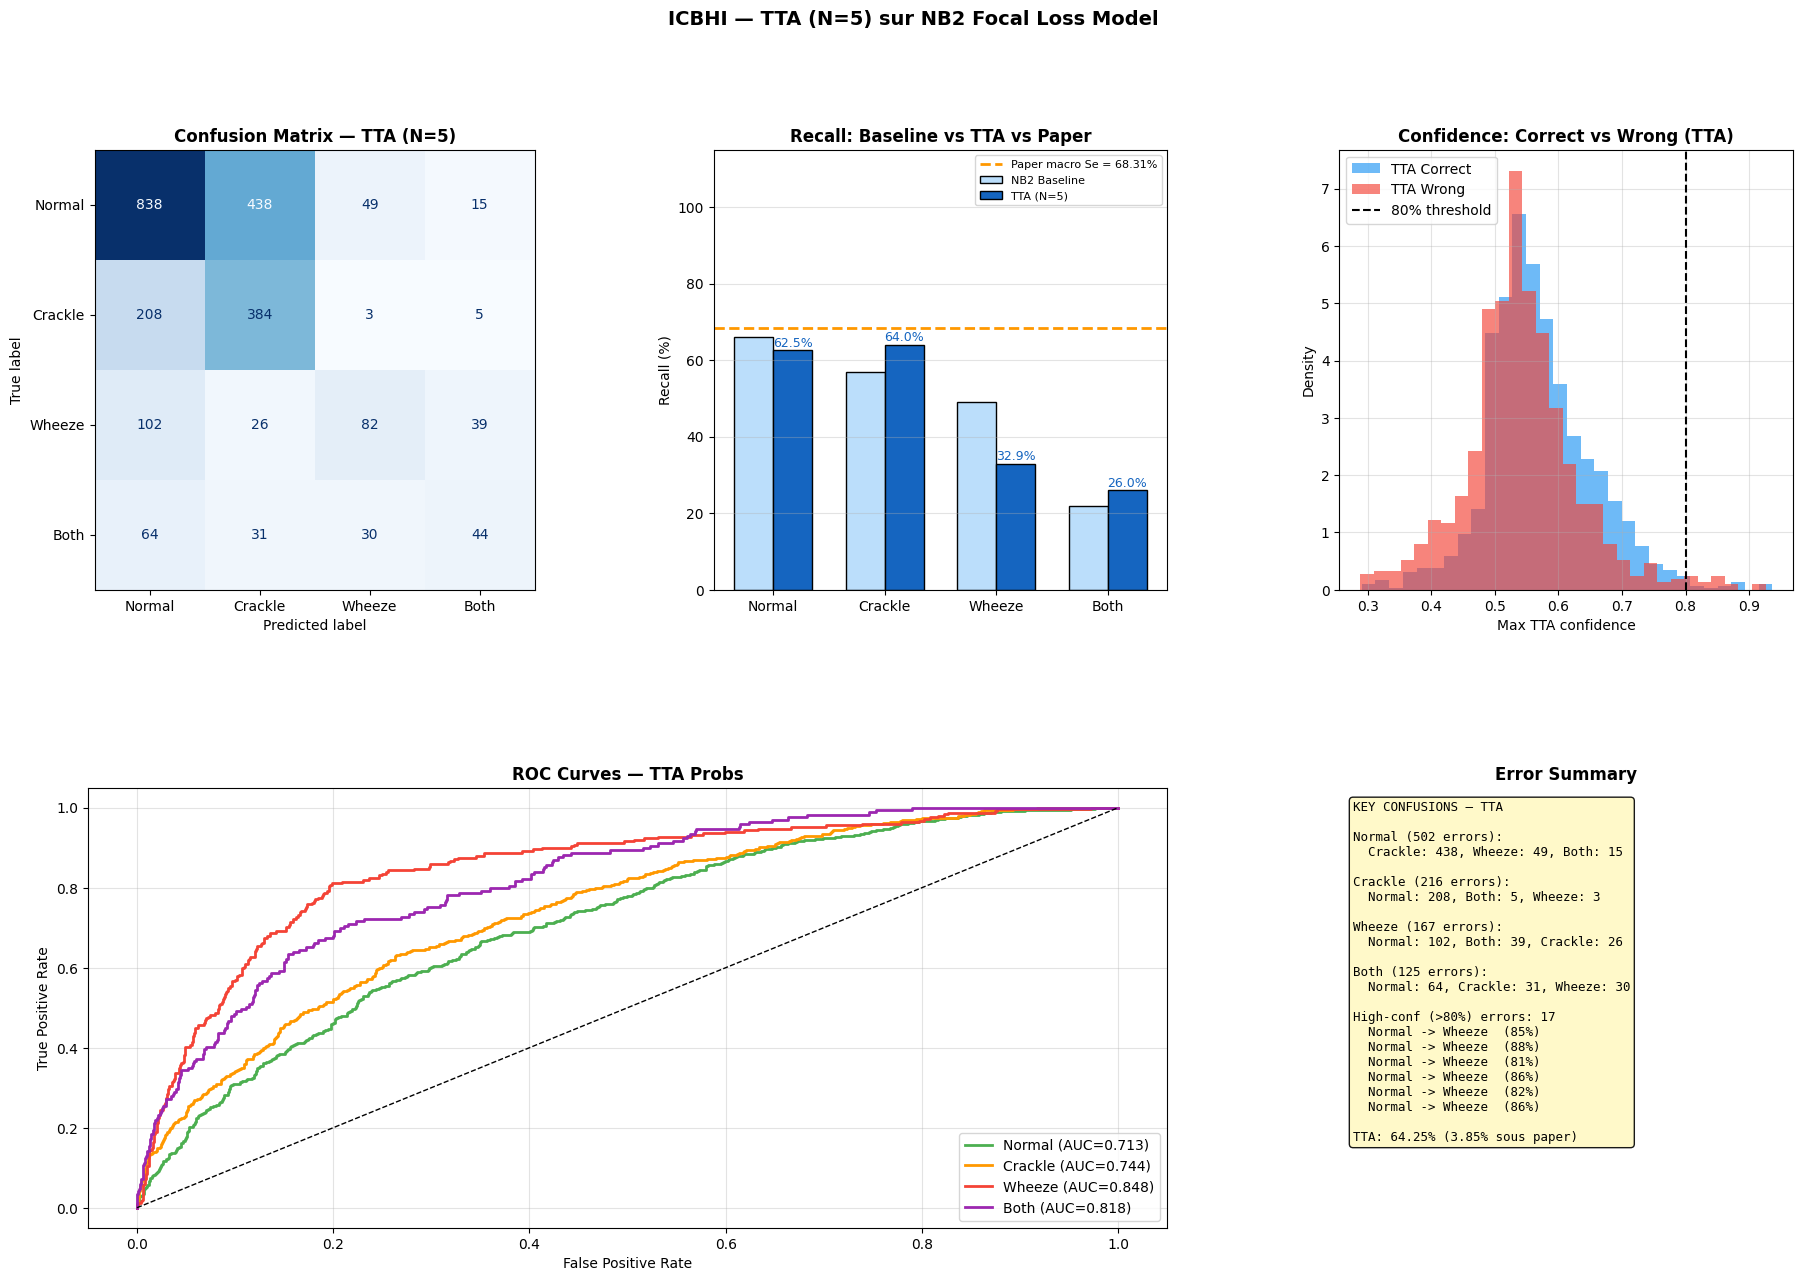

Saved: tta_results.png


In [23]:
import numpy as np, matplotlib.pyplot as plt, matplotlib.gridspec as gridspec
from collections import Counter
from sklearn.metrics import roc_curve, auc, ConfusionMatrixDisplay, confusion_matrix
from sklearn.preprocessing import label_binarize

all_labels     = np.load(f'{CKPT_DIR}/test_labels.npy')
all_probs      = np.load(f'{CKPT_DIR}/test_probs.npy')
all_preds      = np.load(f'{CKPT_DIR}/test_preds.npy')
test_probs_tta = np.load(f'{CKPT_DIR}/test_probs_tta.npy')
test_preds_tta = np.load(f'{CKPT_DIR}/test_preds_tta.npy')
d_test         = np.load(NPZ_PATH)['device_test']

DEVICE_NAMES = ['AKGC417L','LittC2SE','Litt3200','Meditron']
COLORS       = ['#4CAF50','#FF9800','#F44336','#9C27B0']

errors          = test_preds_tta != all_labels
correct         = ~errors
max_conf        = test_probs_tta.max(axis=1)
high_conf_wrong = errors & (max_conf > 0.80)

print('='*65)
print('ERROR ANALYSIS — TTA (N=5)')
print('='*65)
print(f'Total   : {len(all_labels)}  Correct: {correct.sum()} ({correct.mean()*100:.1f}%)  Errors: {errors.sum()} ({errors.mean()*100:.1f}%)')
print('\nPer-class error rate:')
for i, name in enumerate(CLASS_NAMES):
    mask  = all_labels == i
    n_err = (test_preds_tta[mask] != i).sum()
    mc    = Counter(test_preds_tta[mask & errors]).most_common(1)
    mc_s  = f'-> mostly {CLASS_NAMES[mc[0][0]]} ({mc[0][1]}x)' if mc else ''
    print(f'  {name:<9}: {n_err:>4}/{mask.sum():<5} ({n_err/mask.sum()*100:.1f}%)  {mc_s}')
print(f'\nAvg confidence CORRECT : {max_conf[correct].mean()*100:.1f}%')
print(f'Avg confidence WRONG   : {max_conf[errors].mean()*100:.1f}%')
print(f'High-conf (>80%) wrong : {high_conf_wrong.sum()} cases')
print('\nPer-device error rate:')
for d, dname in enumerate(DEVICE_NAMES):
    m = d_test == d
    if not m.any(): continue
    print(f'  {dname:<12}: {m.sum():>4} samples  error rate {(test_preds_tta[m]!=all_labels[m]).mean()*100:.1f}%')

fig = plt.figure(figsize=(22, 14))
gs  = gridspec.GridSpec(2, 3, hspace=0.45, wspace=0.38)

ax1 = fig.add_subplot(gs[0,0])
cm  = confusion_matrix(all_labels, test_preds_tta)
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=ax1, colorbar=False, cmap='Blues')
ax1.set_title('Confusion Matrix — TTA (N=5)', fontweight='bold')

ax2 = fig.add_subplot(gs[0,1])
x   = np.arange(4); w = 0.35
rec_b = [(all_preds[all_labels==i]==i).mean()*100      for i in range(4)]
rec_t = [(test_preds_tta[all_labels==i]==i).mean()*100 for i in range(4)]
ax2.bar(x-w/2, rec_b, w, label='NB2 Baseline', color='#BBDEFB', edgecolor='black')
ax2.bar(x+w/2, rec_t, w, label='TTA (N=5)',    color='#1565C0', edgecolor='black')
ax2.axhline(68.31, color='#FF9800', lw=2, ls='--', label='Paper macro Se = 68.31%')
for i, v in enumerate(rec_t):
    ax2.text(x[i]+w/2, v+1, f'{v:.1f}%', ha='center', fontsize=9, color='#1565C0')
ax2.set_xticks(x); ax2.set_xticklabels(CLASS_NAMES)
ax2.set_ylabel('Recall (%)'); ax2.set_ylim(0, 115)
ax2.set_title('Recall: Baseline vs TTA vs Paper', fontweight='bold')
ax2.legend(fontsize=8); ax2.grid(axis='y', alpha=0.35)

ax3 = fig.add_subplot(gs[0,2])
ax3.hist(max_conf[correct], bins=30, alpha=0.65, color='#2196F3', label='TTA Correct', density=True)
ax3.hist(max_conf[errors],  bins=30, alpha=0.65, color='#F44336', label='TTA Wrong',   density=True)
ax3.axvline(0.8, color='black', ls='--', lw=1.5, label='80% threshold')
ax3.set_xlabel('Max TTA confidence'); ax3.set_ylabel('Density')
ax3.set_title('Confidence: Correct vs Wrong (TTA)', fontweight='bold')
ax3.legend(); ax3.grid(alpha=0.35)

ax4  = fig.add_subplot(gs[1,0:2])
y_bin = label_binarize(all_labels, classes=[0,1,2,3])
for i, (name, color) in enumerate(zip(CLASS_NAMES, COLORS)):
    fpr, tpr, _ = roc_curve(y_bin[:,i], test_probs_tta[:,i])
    ax4.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc(fpr,tpr):.3f})')
ax4.plot([0,1],[0,1],'k--',lw=1)
ax4.set_xlabel('False Positive Rate'); ax4.set_ylabel('True Positive Rate')
ax4.set_title('ROC Curves — TTA Probs', fontweight='bold')
ax4.legend(loc='lower right'); ax4.grid(alpha=0.35)

ax5 = fig.add_subplot(gs[1,2])
ax5.axis('off')
lines = ['KEY CONFUSIONS — TTA\n']
for i, name in enumerate(CLASS_NAMES):
    m = (all_labels==i) & errors
    if not m.any(): continue
    confused = Counter(test_preds_tta[m])
    detail   = ', '.join(f'{CLASS_NAMES[k]}: {v}' for k,v in confused.most_common())
    lines.append(f'{name} ({m.sum()} errors):')
    lines.append(f'  {detail}\n')
lines.append(f'High-conf (>80%) errors: {high_conf_wrong.sum()}')
for idx in np.where(high_conf_wrong)[0][:6]:
    lines.append(f'  {CLASS_NAMES[all_labels[idx]]} -> {CLASS_NAMES[test_preds_tta[idx]]}  ({max_conf[idx]*100:.0f}%)')

paper_icbhi = 68.10
tta_icbhi   = icbhi_score(all_labels, test_preds_tta)*100
lines.append('')
if tta_icbhi >= paper_icbhi:
    lines.append(f'PAPER BATTU: {tta_icbhi:.2f}% >= {paper_icbhi}%')
else:
    lines.append(f'TTA: {tta_icbhi:.2f}% ({paper_icbhi-tta_icbhi:.2f}% sous paper)')

ax5.text(0.03, 0.97, '\n'.join(lines), ha='left', va='top', fontsize=9,
         family='monospace',
         bbox=dict(boxstyle='round', facecolor='#FFF9C4', alpha=0.9),
         transform=ax5.transAxes)
ax5.set_title('Error Summary', fontweight='bold')

plt.suptitle('ICBHI — TTA (N=5) sur NB2 Focal Loss Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('tta_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: tta_results.png')
